In [8]:
import torch 
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [9]:
words = open('names.txt', 'r').read().splitlines()
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)


In [10]:
import random
random.seed(42)
random.shuffle(words)
block_size = 16

In [11]:
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0]*block_size
        for ch in w+'.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:]+[ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y
# divide data sets in to proper segments of traning data, dev/valuation data, and test data
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xval, Yval = build_dataset(words[n1:n2])
Xtest, Ytest = build_dataset(words[n2:])

In [12]:
for x,y in zip(Xtr[:20], Ytr[:20]):
    print(''.join(itos[i.item()] for i in x), '---->', itos[y.item()])

................ ----> y
...............y ----> u
..............yu ----> h
.............yuh ----> e
............yuhe ----> n
...........yuhen ----> g
..........yuheng ----> .
................ ----> d
...............d ----> i
..............di ----> o
.............dio ----> n
............dion ----> d
...........diond ----> r
..........diondr ----> e
.........diondre ----> .
................ ----> x
...............x ----> a
..............xa ----> v
.............xav ----> i
............xavi ----> e


In [13]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None
    def __call__(self, x):
        self.out = x@ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:
    def __init__(self, dim, eps = 1e-5, momentum = 0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        #paramenters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        #buffers (trained with running momentum update)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        #calc forward pass
        if self.training:

            if x.ndim ==2:
                dim = 0
            elif x.ndim ==3:
                dim = (0,1)
            xmean = x.mean(dim, keepdim=True)
            xvar = x.var(dim, keepdim=True, unbiased=True)
            
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)#normalize and make sure we have value under sqrt
        self.out = self.gamma * xhat + self.beta
        #update running stats
        if self.training:
            with torch.no_grad():
                self.running_mean = (1-self.momentum)*self.running_mean + self.momentum*xmean
                self.running_var = (1-self.momentum)*self.running_var + self.momentum*xvar
        return self.out
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

class Embedding:
    def __init__(self, num_embeddings, embedding_dim):
        self.weight = torch.randn((num_embeddings, embedding_dim))
    def __call__(self, idx):
        self.out = self.weight[idx]
        return self.out
    def parameters(self):
        return [self.weight]
    
class FlattenConsecutive:

    def __init__(self,n):
        self.n = n


    def __call__(self, x):
        B,T,C = x.shape
        x = x.view(B, T//self.n, C*self.n)        
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out
    def parameters(self):
        return []
    
class Sequntial:
    def __init__(self, layers):
        self.layers = layers
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
n_embd = 24
n_hidden = 125
g = torch.Generator().manual_seed(2147483647)
flattn_size = 2

model = Sequntial([
        Embedding(vocab_size, n_embd),
        FlattenConsecutive(flattn_size), Linear(n_embd*flattn_size, n_hidden, bias=False), BatchNorm1d(n_hidden),Tanh(),
        FlattenConsecutive(flattn_size), Linear(n_hidden*flattn_size, n_hidden, bias=False), BatchNorm1d(n_hidden),Tanh(),
        FlattenConsecutive(flattn_size), Linear(n_hidden*flattn_size, n_hidden, bias=False), BatchNorm1d(n_hidden),Tanh(),
        FlattenConsecutive(flattn_size), Linear(n_hidden*flattn_size, n_hidden, bias=False), BatchNorm1d(n_hidden),Tanh(),

        Linear(n_hidden, vocab_size),
])

with torch.no_grad():
    model.layers[-1].weight *= 0.1

parameters = model.parameters()
for p in parameters:
    p.requires_grad = True
print(sum(p.nelement() for p in parameters))

104800


In [14]:
torch.manual_seed(42)
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
    xi = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    xb, yb = Xtr[xi], Ytr[xi]
    logits = model(xb)
    loss = F.cross_entropy(logits, yb)
    for p in parameters:
        p.grad = None
    
    lr = 0.1 if i < 100000 else 0.01
    loss.backward()
    for p in parameters:
        p.data += -lr * p.grad

    if i%10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.item())
    with torch.no_grad():
        ud.append([(lr*p.grad.std()/p.data.std()).log10().item() for p in parameters])





      0/200000: 3.2730
  10000/200000: 2.2564
  20000/200000: 1.8856
  30000/200000: 2.2866
  40000/200000: 1.9318
  50000/200000: 1.9477
  60000/200000: 1.9779
  70000/200000: 1.6837
  80000/200000: 2.1200
  90000/200000: 1.9771
 100000/200000: 1.9418
 110000/200000: 1.6704
 120000/200000: 1.6425
 130000/200000: 1.6871
 140000/200000: 1.7664
 150000/200000: 2.0742
 160000/200000: 1.4585
 170000/200000: 1.8195
 180000/200000: 1.7886
 190000/200000: 2.0184


In [15]:
for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (32, 16, 24)
FlattenConsecutive : (32, 8, 48)
Linear : (32, 8, 125)
BatchNorm1d : (32, 8, 125)
Tanh : (32, 8, 125)
FlattenConsecutive : (32, 4, 250)
Linear : (32, 4, 125)
BatchNorm1d : (32, 4, 125)
Tanh : (32, 4, 125)
FlattenConsecutive : (32, 2, 250)
Linear : (32, 2, 125)
BatchNorm1d : (32, 2, 125)
Tanh : (32, 2, 125)
FlattenConsecutive : (32, 250)
Linear : (32, 125)
BatchNorm1d : (32, 125)
Tanh : (32, 125)
Linear : (32, 27)


In [16]:
# evaluate the loss
@torch.no_grad() # this decorator disables gradient tracking inside pytorch
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xval, Yval),
    'test': (Xtest, Ytest),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.727562665939331
val 2.0152933597564697


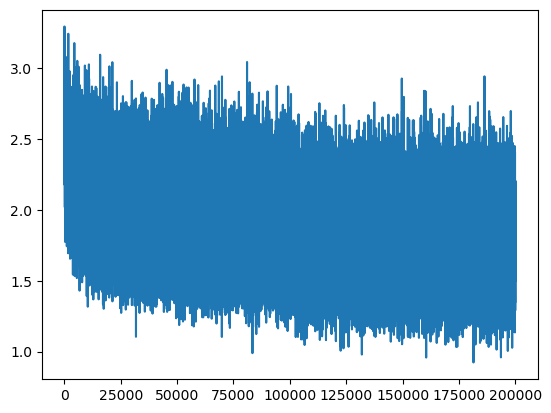

In [17]:
plt.plot(lossi)
plt.show()

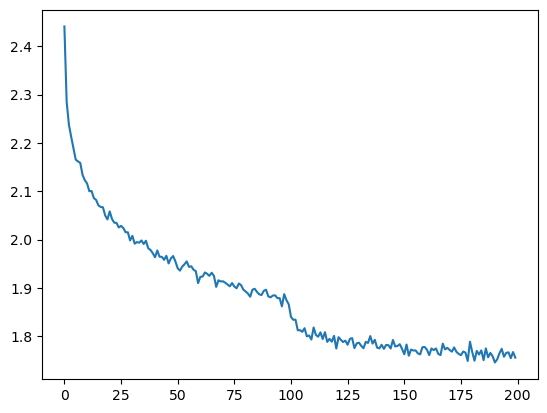

In [18]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1))
plt.show()

layer 4 (      Tanh): mean +0.03, std 0.46, saturated: 9.92%
layer 8 (      Tanh): mean -0.01, std 0.49, saturated: 13.61%
layer 12 (      Tanh): mean +0.02, std 0.63, saturated: 19.48%
layer 16 (      Tanh): mean -0.01, std 0.59, saturated: 8.17%


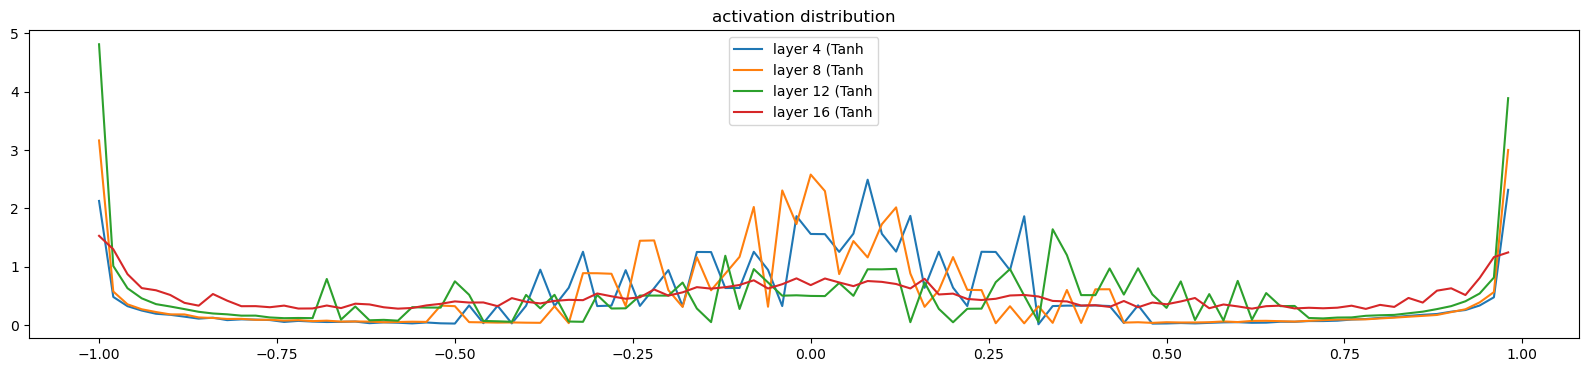

In [19]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(model.layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')


plt.show()

In [20]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(model.layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')


AttributeError: 'NoneType' object has no attribute 'mean'

weight   (27, 24) | mean -0.000000 | std 1.392946e-02 | grad:data ratio 1.330610e-02
weight  (48, 125) | mean -0.000269 | std 9.747374e-03 | grad:data ratio 3.164646e-02
weight (250, 125) | mean +0.000037 | std 6.995146e-03 | grad:data ratio 3.715466e-02
weight (250, 125) | mean -0.000010 | std 7.675854e-03 | grad:data ratio 4.409824e-02
weight (250, 125) | mean -0.000007 | std 4.885475e-03 | grad:data ratio 3.647981e-02
weight  (125, 27) | mean +0.000000 | std 1.544198e-02 | grad:data ratio 6.750951e-02


C:\Users\zac23\AppData\Local\Temp\ipykernel_11868\3788849590.py:7: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))


<Figure size 2000x400 with 0 Axes>

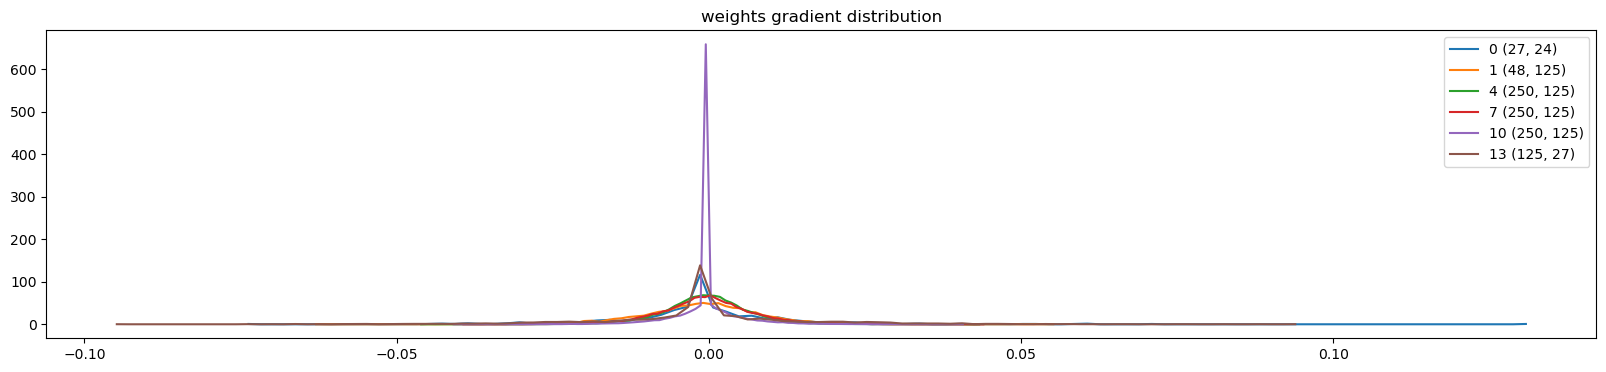

In [21]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');




plt.show()

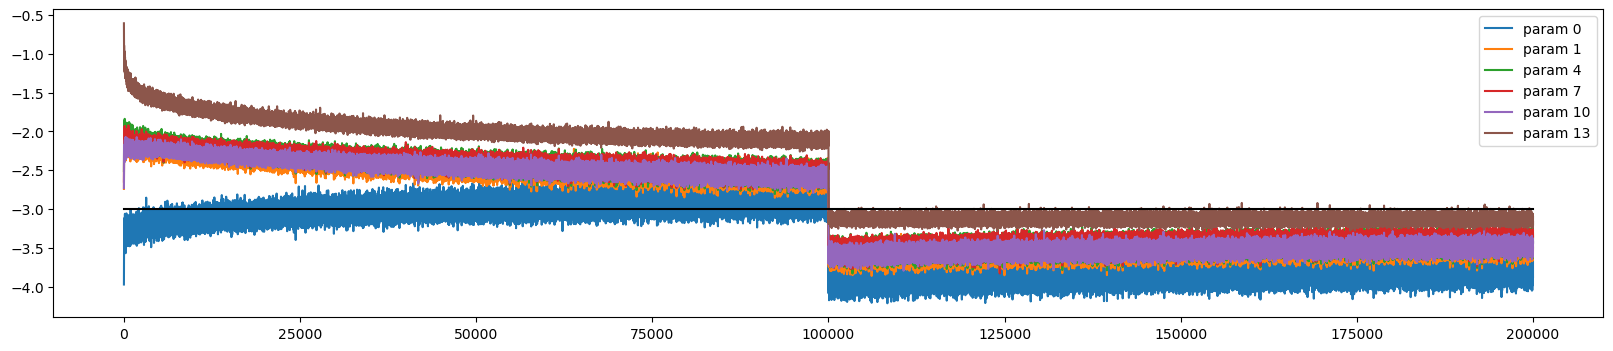

In [22]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);


plt.show()